In [31]:
import os
import pandas as pd
from collections import Counter

def count_occurence(_data):
    counter = Counter(_data)

    occurrences = [0] * 5
    for _index in range(1, 6):
        occurrences[_index - 1] = round(counter.get(_index, 0) / len(_data) * 100, 3)

    return occurrences

likert_figures_path = '../../generated/figures/likert'

likert_csv = '../../generated/forms/'

forms_data_csv_path = '../../generated/forms/data.csv'
likert_questions_csv_path = '../../data/forms/likert_questions.csv'

In [32]:
if not os.path.exists(forms_data_csv_path):
    raise FileNotFoundError(
        f"Le fichier {forms_data_csv_path} n'existe pas. Exécutez le notebook 'notebooks/arrange data/Database data.ipynb' pour le générer.")


df_data = pd.read_csv(forms_data_csv_path)
# print(list(filter(lambda x: x.startswith("S-Quel"), df_data.columns)))
df_data.columns = df_data.columns.str.replace('\\s*\r\n|\\s*\r|\\s*\n', ' ', regex=True)
# print(list(filter(lambda x: x.startswith("S-Quel"), df_data.columns)))
df_data

,ID,En quelle année d'étude êtes vous ?,Quels outils gamifiés avez vous déjà utilisé ?,Comment évaluez-vous votre connaissance de Java?,Comment évaluez-vous votre compétence en tests logiciels ?,Comment évaluez-vous votre motivation à écrire des tests logiciels ?,Je voudrais utiliser ce système fréquemment.,Ce système est inutilement complexe.,Ce système est facile à utiliser.,J'aurais besoin du soutien d'un technicien pour être capable d'utiliser ce système.,...,J'étais plus motivé à écrire des tests avec le mode de jeu que d'habitude.,Le système de mode de jeu m'incite à écrire plus de tests.,Mon engouement pour un système gamifié avec uniquement un mode de jeu diminuerait au file du temps (plusieurs semaines/mois/années) (sentiment de lassitude).,Les succès donnaient des objectifs clairs.,Le feedback des succès était suffisant pour connaitre mon avancement.,mode,Avoir des succès d'équipe vous a.,Dépendre des autres pour débloquer les succès vous a.,Savoir que vous deviez débloquer un palier pour permettre à vos coéquipiers d'accéder à des succès vous a.,Il y avait une ambiance de compétition dans l'équipe.
0,1,Master 1,Kahoot;Duolinguo;Wooclap;,Intermédiaire,Intermédiaire,3,3.0,1.0,5.0,1.0,...,4.0,5.0,4.0,5.0,5.0,solo,NaN,NaN,NaN,NaN
1,2,Master 1,Kahoot;Duolinguo;Github Achievements;,Avancé(e),Avancé(e),3,2.0,1.0,5.0,1.0,...,4.0,3.0,2.0,3.0,4.0,équipe,4.0,3.0,4.0,2.0
2,3,Master 1,Kahoot;Duolinguo;Github Achievements;,Intermédiaire,Avancé(e),4,3.0,2.0,4.0,2.0,...,4.0,4.0,4.0,5.0,5.0,équipe,5.0,5.0,5.0,3.0
3,4,Master 1,Kahoot;Duolinguo;,Intermédiaire,Novice,1,4.0,1.0,4.0,2.0,...,4.0,4.0,2.0,3.0,3.0,solo,NaN,NaN,NaN,NaN
4,5,Master 1,Duolinguo;Kahoot;,Intermédiaire,Novice,3,4.0,2.0,5.0,2.0,...,3.0,4.0,2.0,5.0,3.0,solo,NaN,NaN,NaN,NaN
5,7,Master 1,Github Achievements;,Intermédiaire,Novice,2,3.0,3.0,2.0,4.0,...,3.0,2.0,2.0,1.0,2.0,équipe,3.0,3.0,3.0,2.0
6,8,UES (passerelle),Github Achievements;Duolinguo;,Avancé(e),Avancé(e),3,3.0,1.0,4.0,1.0,...,4.0,5.0,2.0,5.0,5.0,solo,NaN,NaN,NaN,NaN
7,9,Master 1,Duolinguo;,Intermédiaire,Novice,4,3.0,2.0,3.0,1.0,...,3.0,4.0,3.0,3.0,2.0,équipe,2.0,2.0,1.0,3.0
8,10,Master 1,Duolinguo;,Avancé(e),Intermédiaire,3,4.0,2.0,4.0,3.0,...,4.0,4.0,3.0,4.0,3.0,équipe,2.0,2.0,5.0,2.0
9,11,Master 1,Kahoot;Duolinguo;,Avancé(e),Avancé(e),3,3.0,2.0,5.0,1.0,...,4.0,3.0,5.0,5.0,5.0,solo,NaN,NaN,NaN,NaN


# Forms

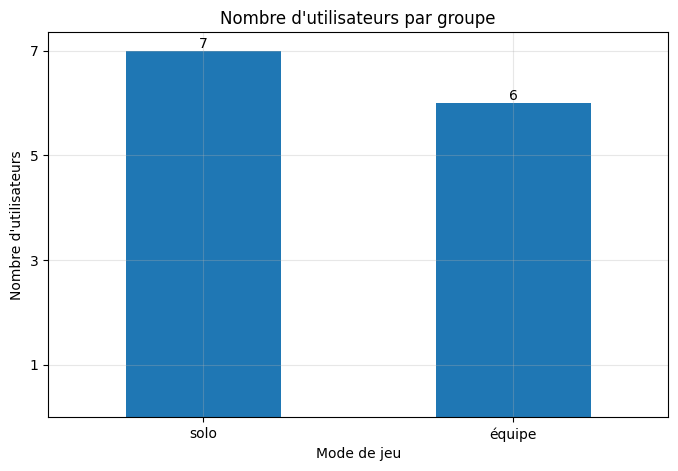

In [33]:
import matplotlib.pyplot as plt

users_by_groups = df_data.groupby('mode')['ID'].count()
plt.figure(figsize=(8, 5))
bars = users_by_groups.plot(kind='bar', stacked=True)
plt.title('Nombre d\'utilisateurs par groupe')
plt.xlabel('Mode de jeu')
plt.ylabel('Nombre d\'utilisateurs')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.yticks(range(1, int(max(users_by_groups)) + 1, 2))

# Add value labels above each bar
for i, v in enumerate(users_by_groups):
    plt.text(i, v, str(v), ha='center', va='bottom')

os.makedirs('../../generated/figures/forms', exist_ok=True)
plt.savefig('../../generated/figures/forms/users_by_groups.pdf', dpi=300, bbox_inches='tight')

plt.show()


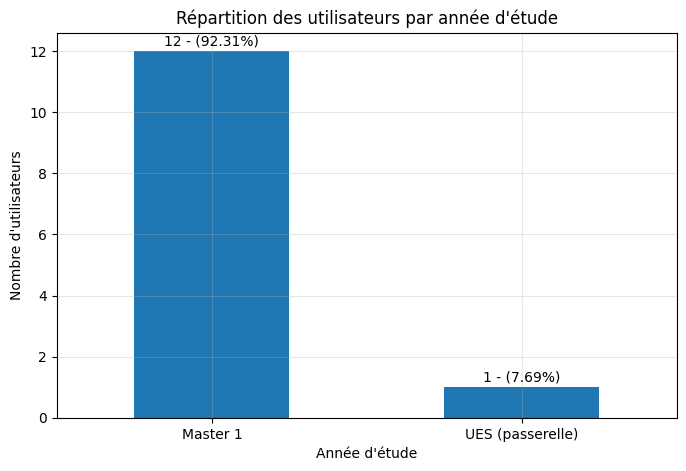

In [34]:
users_by_years = df_data.groupby('En quelle année d\'étude êtes vous ?')['ID'].count()

plt.figure(figsize=(8, 5))
bars = users_by_years.plot(kind='bar', stacked=True)
plt.title('Répartition des utilisateurs par année d\'étude')
plt.xlabel('Année d\'étude')
plt.ylabel('Nombre d\'utilisateurs')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)

# Add value labels above each bar
for i, v in enumerate(users_by_years):
    plt.text(i, v + 0.1, f"{v} - ({round(v / users_by_years.sum() * 100, 2)}%)", ha='center', va='bottom')

os.makedirs('../../generated/figures/forms', exist_ok=True)
plt.savefig('../../generated/figures/forms/users_by_years.pdf', dpi=300, bbox_inches='tight')

plt.show()

# Outils gamifiés

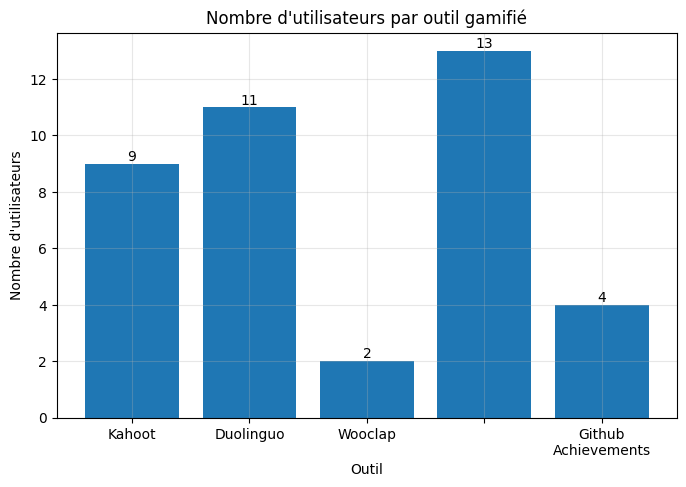

In [35]:
# Split les réponses et compte les occurrences
outils_reponses = df_data['Quels outils gamifiés avez vous déjà utilisé ?']

# Count null values and create list with "Rien" for nulls
outils_split = [['Rien'] if pd.isna(outils) else outils.split(';') for outils in outils_reponses]
outils_flat = [outil.strip() for sublist in outils_split for outil in sublist]
outils_count = Counter(outils_flat)

# Move "Rien" to end by recreating Counter with ordered items
items = [(k, v) for k, v in outils_count.items() if k != 'Rien']
if 'Rien' in outils_count:
    items.append(('Rien', outils_count['Rien']))
outils_count = Counter(dict(items))

# Affichage des résultats
plt.figure(figsize=(8, 5))
plt.bar(outils_count.keys(), outils_count.values())
plt.title('Nombre d\'utilisateurs par outil gamifié')
plt.xlabel('Outil')
plt.ylabel('Nombre d\'utilisateurs')
plt.grid(True, alpha=0.3)

# Format x labels with newlines
labels = ['\n'.join(k.split()) for k in outils_count.keys()]
plt.xticks(range(len(labels)), labels)

# Ajouter les valeurs au-dessus des barres
for i, (k, v) in enumerate(outils_count.items()):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.savefig('../../generated/figures/forms/users_by_tools.pdf', dpi=300, bbox_inches='tight')
plt.show()


# Niveau initial

<Figure size 1000x500 with 0 Axes>

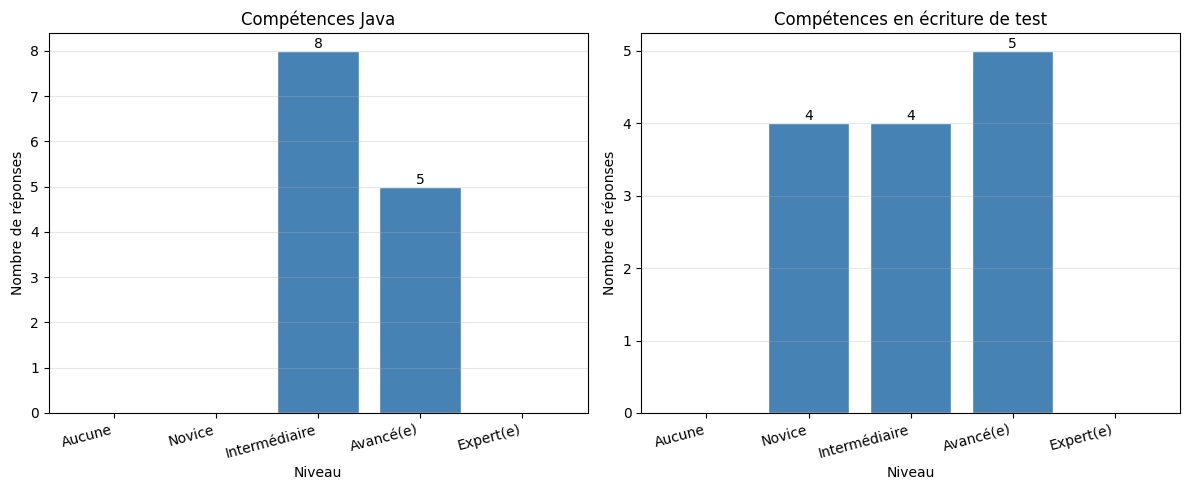

In [36]:
import numpy as np

plt.figure(figsize=(10, 5))

# Get data for the two questions
java_comp = df_data['Comment évaluez-vous votre connaissance de Java?']
test_comp = df_data['Comment évaluez-vous votre compétence en tests logiciels ?']
# Define the 5 levels
levels = ['Aucune', 'Novice', 'Intermédiaire', 'Avancé(e)', 'Expert(e)']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

def plot_levels(ax, series, title):
    # Map existing values to the 5 categories (adjust mapping to your actual data)
    counts = series.value_counts().reindex(levels, fill_value=0)
    
    x = np.arange(len(levels))
    bars = ax.bar(x, counts.values, color='steelblue', edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Niveau')
    ax.set_ylabel('Nombre de réponses')
    ax.set_xticks(x)
    ax.set_xticklabels(levels, rotation=15, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    for bar, v in zip(bars, counts.values):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, v, str(v), ha='center', va='bottom')

plot_levels(ax1, java_comp, 'Compétences Java')
plot_levels(ax2, test_comp, 'Compétences en écriture de test')

plt.tight_layout()
plt.savefig('../../generated/figures/forms/initial_level.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Likerts

In [37]:
if not os.path.exists(likert_questions_csv_path):
    raise FileNotFoundError(
        f"Le fichier {likert_questions_csv_path} n'existe pas. Exécutez le script '../../FormsAppsScripts.gs' dans google drive pour le générer.")

df_likert_questions = pd.read_csv(likert_questions_csv_path, sep=',').drop(columns=['Type'])
df_likert_questions["Titre"] = df_likert_questions["Formulaire"].str[0].str.upper() + "-" + df_likert_questions["Titre"].str.replace('\r\n|\n|\r| \r\n', ' ', regex=True).str.strip()
df_likert_questions


,Formulaire,Titre,Label_1,Label_2,Label_3,Label_4,Label_5
0,demographic,D-Comment évaluez-vous votre connaissance de J...,Aucune,Novice,Intermédiaire,Avancé(e),Expert(e)
1,demographic,D-Comment évaluez-vous votre compétence en tes...,Aucune,Novice,Intermédiaire,Avancé(e),Expert(e)
2,demographic,D-Comment évaluez-vous votre motivation à écri...,Faible,Plutôt faible,Moyenne,Plutôt élevée,Élevée
3,sus,S-Je voudrais utiliser ce système fréquemment.,Pas du tout d'accord,Relativement pas d'accord,Moyennement d'accord,Assez d'accord,Tout à fait d'accord
4,sus,S-Ce système est inutilement complexe.,Pas du tout d'accord,Relativement pas d'accord,Moyennement d'accord,Assez d'accord,Tout à fait d'accord
5,sus,S-Ce système est facile à utiliser.,Pas du tout d'accord,Relativement pas d'accord,Moyennement d'accord,Assez d'accord,Tout à fait d'accord
6,sus,S-J'aurais besoin du soutien d'un technicien p...,Pas du tout d'accord,Relativement pas d'accord,Moyennement d'accord,Assez d'accord,Tout à fait d'accord
7,sus,S-Les différentes fonctionnalités de ce systèm...,Pas du tout d'accord,Relativement pas d'accord,Moyennement d'accord,Assez d'accord,Tout à fait d'accord
8,sus,S-Il y a trop d'incohérences dans ce système.,Pas du tout d'accord,Relativement pas d'accord,Moyennement d'accord,Assez d'accord,Tout à fait d'accord
9,sus,S-La plupart des gens apprendront à utiliser c...,Pas du tout d'accord,Relativement pas d'accord,Moyennement d'accord,Assez d'accord,Tout à fait d'accord


In [44]:
likert_by_label = {}
answers = df_data.transpose()
level_map = {'Aucune': 1, 'Novice': 2, 'Intermédiaire': 3, 'Avancé(e)': 4, 'Expert(e)': 5}
df_data['Comment évaluez-vous votre connaissance de Java?'] = df_data['Comment évaluez-vous votre connaissance de Java?'].map(level_map)
df_data['Comment évaluez-vous votre compétence en tests logiciels ?'] = df_data['Comment évaluez-vous votre compétence en tests logiciels ?'].map(level_map)


for index, row in df_likert_questions.iterrows():
    titre = row["Titre"][2:]
    category = row["Label_1"] + "-" + row["Label_2"] + "-" + row["Label_3"] + "-" + row["Label_4"]+ "-" + row["Label_5"]

    if category not in likert_by_label:
        likert_by_label[category] = {}

    if titre in answers.index:
        likert_by_label[category][titre] = count_occurence(answers.loc[titre].values.tolist())
    else:
        print(titre + " not in index")

In [45]:
likert_by_label

{'Aucune-Novice-Intermédiaire-Avancé(e)-Expert(e)': {'Comment évaluez-vous votre connaissance de Java?': [0.0,
   0.0,
   61.538,
   38.462,
   0.0],
  'Comment évaluez-vous votre compétence en tests logiciels ?': [0.0,
   30.769,
   30.769,
   38.462,
   0.0]},
 'Faible-Plutôt faible-Moyenne-Plutôt élevée-Élevée': {'Comment évaluez-vous votre motivation à écrire des tests logiciels ?': [7.692,
   15.385,
   53.846,
   23.077,
   0.0]},
 "Pas du tout d'accord-Relativement pas d'accord-Moyennement d'accord-Assez d'accord-Tout à fait d'accord": {'Je voudrais utiliser ce système fréquemment.': [0.0,
   23.077,
   53.846,
   23.077,
   0.0],
  'Ce système est inutilement complexe.': [53.846, 38.462, 7.692, 0.0, 0.0],
  'Ce système est facile à utiliser.': [0.0, 7.692, 7.692, 38.462, 46.154],
  "J'aurais besoin du soutien d'un technicien pour être capable d'utiliser ce système.": [38.462,
   46.154,
   7.692,
   7.692,
   0.0],
  'Les différentes fonctionnalités de ce système sont bien inté

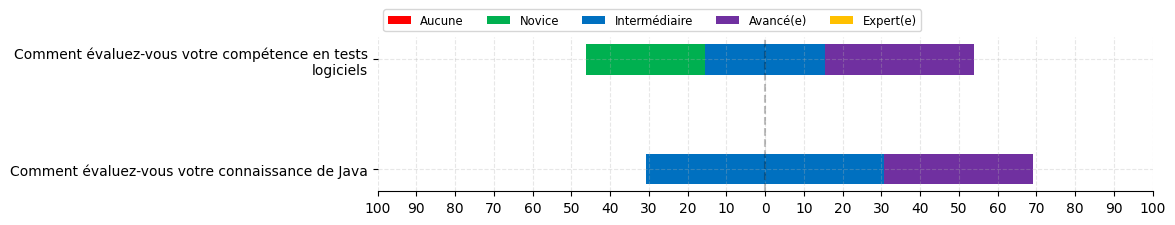

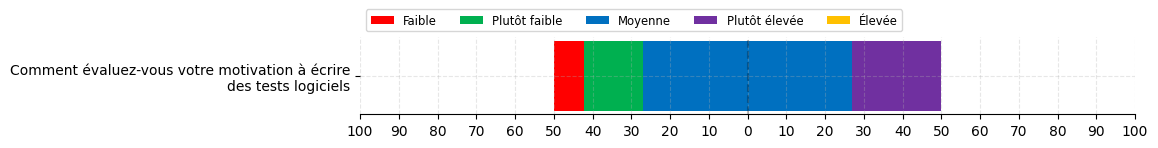

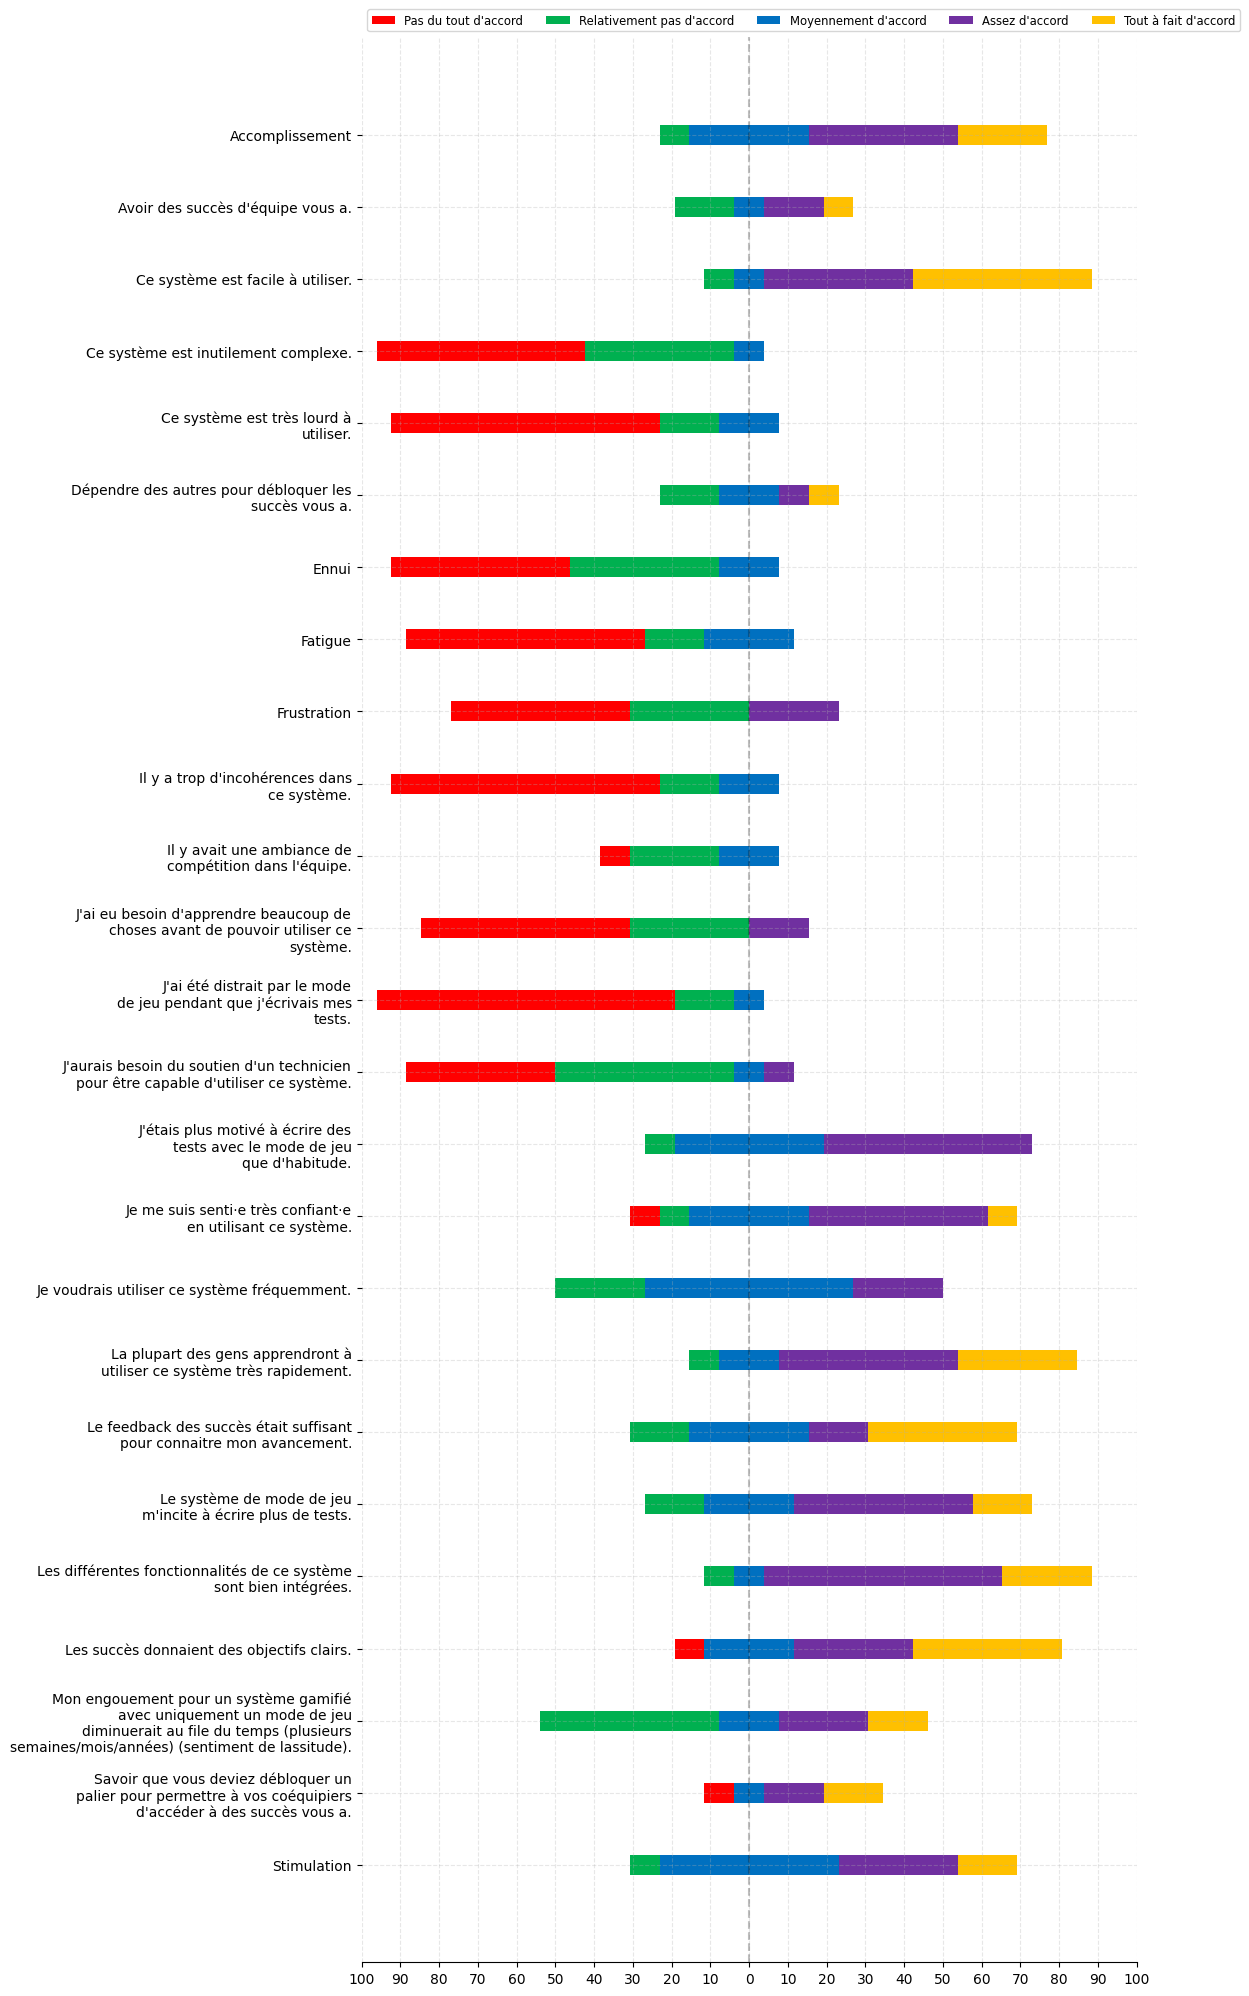

In [46]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if not os.path.exists(likert_figures_path):
    os.makedirs(likert_figures_path)

colors = ['#FF0000', '#00B050', '#0070C0', '#7030A0', '#FFC000']

categories_label = {
    "Accomplissement": "Accomplissant",
    "Frustration": "Frustant",
    "Fatigué·e": "Fatiguant",
    "Stimulé·e": "Stimulant",
    "Mauvais": "Mal intégré",
    "Très bon": "Bien intégré",
    "Pas du tout": "En désaccord",
    "Tout à fait": "D'accord",
    "1":"Pas du tout d'accord",
    "2":"Relativement pas d'accord",
    "3":"Moyennement d'accord",
    "4":"Assez d'accord",
    "5":"Tout à fait d'accord"
}

labels_to_reverse = ['Facile', 'Accomplissement']

all_results = []

for category, results in likert_by_label.items():
    l1, l2, l3, l4, l5 = category.split("-")
    label_1 = categories_label[l1] if l1 in categories_label else l1
    label_2 = categories_label[l2] if l2 in categories_label else l2
    label_3 = categories_label[l3] if l3 in categories_label else l3
    label_4 = categories_label[l4] if l4 in categories_label else l4
    label_5 = categories_label[l5] if l5 in categories_label else l5

    category_names = [ label_1, label_2, label_3, label_4, label_5]

    sorted_items = sorted(results.items(), key=lambda x: x[0].lower())
    labels = ['\n'.join(
        [' '.join(label.strip('? \n').split()[i:i + 6]) for i in range(0, len(label.strip('? \n').split()), 6)]) for
              label, _ in sorted_items]
    data = np.array([value for _, value in sorted_items])


    # Create dataframe with percentages for current category  
    df_results = pd.DataFrame(data, columns=['1', '2', '3', '4', '5'], index=list(map(lambda x: x[0].replace("\"", "").replace("(", ""), sorted_items)))
    df_results['Category'] = f"{label_1}-{label_5}"
    df_results['% Left (1-2)'] = df_results[['1', '2']].sum(axis=1)
    df_results['% Right (4-5)'] = df_results[['4', '5']].sum(axis=1)

    all_results.append(df_results)

    data_cum = data.cumsum(axis=1)
    middle_index = data.shape[1] // 2
    offsets = data[:, range(middle_index)].sum(axis=1) + data[:, middle_index] / 2

    num_items = len(labels)
    fig_height = num_items

    fig, ax = plt.subplots(figsize=(10, fig_height))

    for i, (colname, color) in enumerate(zip(category_names, colors)):
        widths = data[:, i]
        starts = data_cum[:, i] - widths - offsets
        height = 20 / 72
        rects = ax.barh(labels, widths, left=starts, height=height, label=colname, color=color)

    ax.axvline(0, linestyle='--', color='black', alpha=.25)
    ax.set_xlim(-100, 100)
    ax.set_xticks(np.arange(-100, 101, 10))
    ax.xaxis.set_major_formatter(lambda x, pos: str(abs(int(x))))
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.invert_yaxis()
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.legend(ncol=len(category_names), bbox_to_anchor=(0, 1), loc='lower left', fontsize='small')
    fig.set_facecolor('#FFFFFF')
    fig.savefig(f"{likert_figures_path}/{label_1.replace(" ", "_")}_{label_5.replace(" ", "_")}.pdf", dpi=300, bbox_inches='tight')

final_df = pd.concat(all_results)
final_df.to_csv(f"{likert_csv}/likert_data.csv")

In [41]:
def likert_chart(questions_filter, category, image_name):
    l1, l2, l3, l4, l5 = category.split("-")
    label_1 = categories_label[l1] if l1 in categories_label else l1
    label_2 = categories_label[l2] if l2 in categories_label else l2
    label_3 = categories_label[l3] if l3 in categories_label else l3
    label_4 = categories_label[l4] if l4 in categories_label else l4
    label_5 = categories_label[l5] if l5 in categories_label else l5
    category_names = [ label_1, label_2, label_3, label_4, label_5]

    filtered_data = {k: v for k, v in likert_by_label[category].items() if any(f in k.lower() for f in questions_filter)}
    sorted_items = sorted(filtered_data.items(), key=lambda x: x[0].lower())

    labels = ['\n'.join([' '.join(label.strip('? \n').split()[i:i + 6])
                         for i in range(0, len(label.strip('? \n').split()), 6)])
              for label, _ in sorted_items]
    data = np.array([value for _, value in sorted_items])

    data_cum = data.cumsum(axis=1)
    middle_index = data.shape[1] // 2
    offsets = data[:, range(middle_index)].sum(axis=1) + data[:, middle_index] / 2

    num_items = len(labels)
    fig_height = num_items

    fig, ax = plt.subplots(figsize=(10, fig_height))

    for i, (colname, color) in enumerate(zip(category_names, colors)):
        widths = data[:, i]
        starts = data_cum[:, i] - widths - offsets
        height = 20 / 72
        rects = ax.barh(labels, widths, left=starts, height=height, label=colname, color=color)

    ax.axvline(0, linestyle='--', color='black', alpha=.25)
    ax.set_xlim(-100, 100)
    ax.set_xticks(np.arange(-100, 101, 10))
    ax.xaxis.set_major_formatter(lambda x, pos: str(abs(int(x))))
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.invert_yaxis()
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.legend(ncol=len(category_names), bbox_to_anchor=(0, 1), loc='lower left', fontsize='small')
    fig.set_facecolor('#FFFFFF')

    if not os.path.exists(likert_figures_path):
        os.makedirs(likert_figures_path)

    fig.savefig(f"{likert_figures_path}/{image_name}.pdf", dpi=300, bbox_inches='tight')

    return [question for question, _ in sorted_items]


# Stat non applicables car échantillon trop petit

# Fatigue

In [ ]:
import numpy as np
from scipy.stats import mannwhitneyu

df_team =  df_data[df_data['mode'] == 'équipe']
df_solo =  df_data[df_data['mode'] == 'solo']

team_fatigue = df_team["Fatigue"]
solo_fatigue = df_solo["Fatigue"]

stat, p = mannwhitneyu(team_fatigue, solo_fatigue, alternative='two-sided')
print("Statistique de Mann-Whitney U :", stat)
print("p-value :", p)



Statistique de Mann-Whitney U : 23.5
p-value : 0.7423729588403167


# Distraction

Statistique de Wilcoxon : 111.0
p-value : 0.09115345448723068
0.6142857142857143 - Effet moyen - achievements


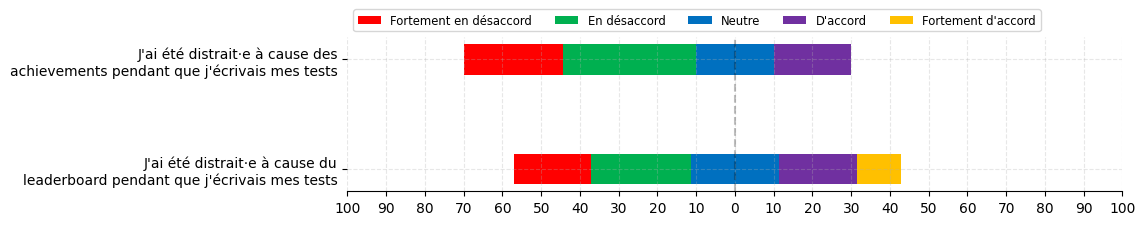

In [ ]:
from scipy.stats import wilcoxon

questions_filter = ['distrait']
category = 'Pas du tout-Tout à fait'
questions = likert_chart(questions_filter, category, "distraction")

achievements_distract = df_data["A-J'ai été distrait·e à cause des achievements pendant que j'écrivais mes tests ?"]
leaderboard_distract = df_data["L-J'ai été distrait·e à cause du leaderboard pendant que j'écrivais mes tests ?"]

stat, p = wilcoxon(achievements_distract, leaderboard_distract)
print("Statistique de Wilcoxon :", stat)
print("p-value :", p)

a12 = tests.vargha_delaney_a12(achievements_distract, leaderboard_distract)
a12_label = tests.a12_label(a12)
better_mode = "equals" if a12 == 0.5 else "leaderboard" if a12 < 0.5 else "achievements"

print(a12, "-", a12_label, "-", better_mode)

# Motivation

In [ ]:
motivation_before = df_data["D-Motivation initiale à écrire des tests"]
motivation_after = df_data["S-Après avoir utilisé le plugin, j'évalue ma motivation à écrire des tests"]

stat, p = wilcoxon(motivation_before, motivation_after)
print("Statistique de Wilcoxon :", stat)
print("p-value :", p)

a12 = tests.vargha_delaney_a12(motivation_before, motivation_after)
a12_label = tests.a12_label(a12)

print(a12, "-", a12_label)

print("-------------------")

motivation_achievements = df_data["A-Motivation à écrire des tests avec le système d'achievements"]
motivation_leaderboard = df_data["L-Motivation à écrire des tests avec le système de leaderboard"]

stat, p = wilcoxon(motivation_leaderboard, motivation_achievements)
print("Statistique de Wilcoxon :", stat)
print("p-value :", p)

a12 = tests.vargha_delaney_a12(motivation_achievements, motivation_leaderboard)
a12_label = tests.a12_label(a12)

print(a12, "-", a12_label)

Statistique de Wilcoxon : 51.0
p-value : 0.0018997682733618057
0.6857142857142857 - Effet moyen
-------------------
Statistique de Wilcoxon : 148.0
p-value : 0.9515142673904153
0.5285714285714286 - Aucun effet


# Fun

['Selon vous, quel mode est le plus fun ?']

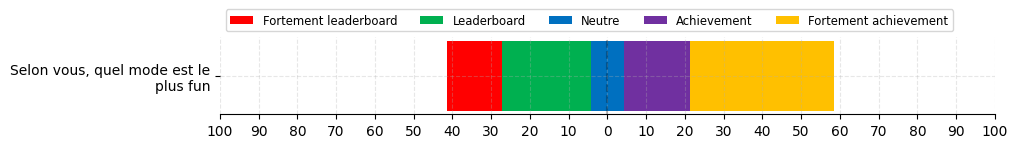

In [ ]:
questions_filter = ['fun']
category = 'Leaderboard-Achievement'
likert_chart(questions_filter, category, "fun")

["Quel mode j'ai envie d'utiliser dans un cours où je peux être confronté à du test logiciel ? (Vérification et Validation, Génie Logiciel, ..)"]

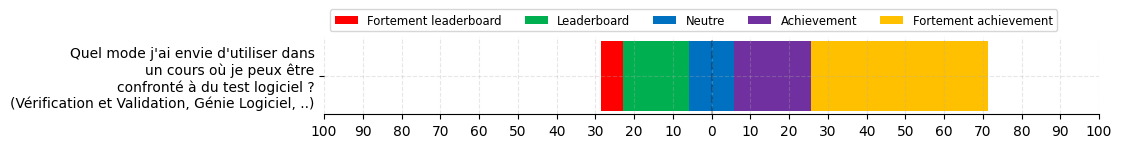

In [ ]:
questions_filter = ['cours']
category = 'Leaderboard-Achievement'
likert_chart(questions_filter, category, "cours-game-mode")

["Seriez-vous intéressé·e par l'utilisation d'outils gamifiés durant certains cours ? (Vérification et Validation, Génie Logiciel, ..)",
 'Votre intérêt pour un système gamifié avec uniquement des achievements diminuerait-il au fil du temps (plusieurs semaines/mois/années) ? (Sentiment de lassitude)',
 'Votre intérêt pour un système gamifié avec uniquement un leaderboard diminuerait-il au fil du temps (plusieurs semaines/mois/années) ? (Sentiment de lassitude)']

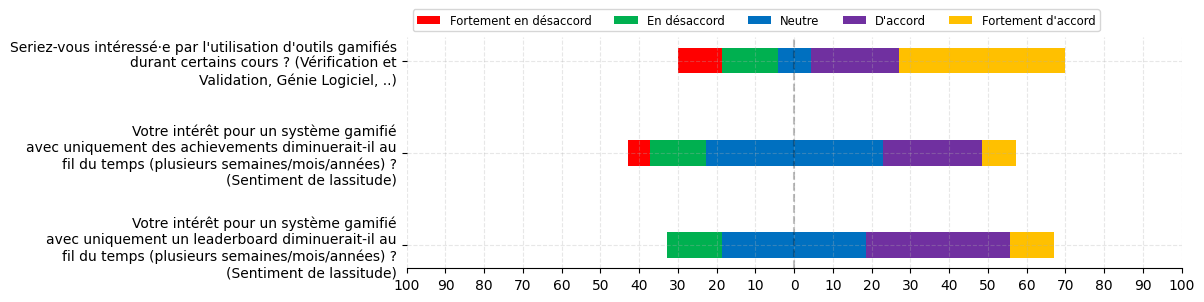

In [ ]:
questions_filter = ['cours', 'intérêt']
category = 'Pas du tout-Tout à fait'
likert_chart(questions_filter, category, "interet-cours")

# Système préféré

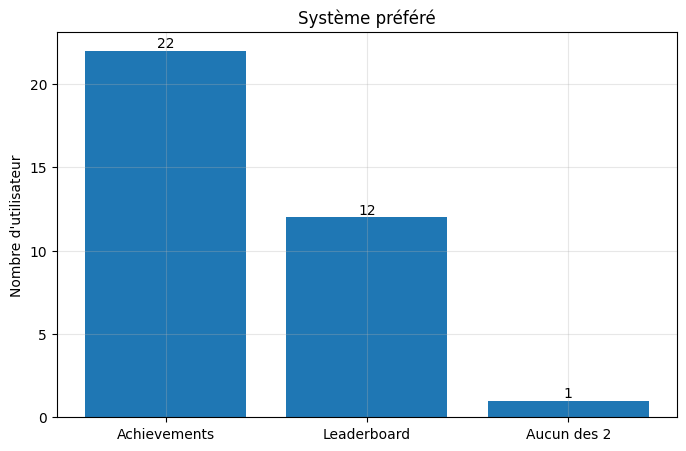

S-Système préféré
Achievements    22
Leaderboard     12
Aucun des 2      1
Name: count, dtype: int64

In [ ]:
systems_data = df_data['S-Système préféré']
system_counts = systems_data.value_counts()
system_proportions = system_counts

plt.figure(figsize=(8, 5))
plt.bar(system_proportions.index, system_proportions.values)
plt.title('Système préféré')
plt.ylabel("Nombre d'utilisateur")
plt.grid(True, alpha=0.3)

# Add percentage labels on top of bars
for i, v in enumerate(system_proportions.values):
    plt.text(i, v, v, ha='center', va='bottom')

plt.savefig('../../generated/figures/forms/preferred_system.pdf', dpi=300, bbox_inches='tight')
plt.show()
system_counts

# Questions ouvertes